# Override Confidence Model — All 15 Pairs (features_6)

Direct continuation of `notebooks_6/04_meta_confidence_model.ipynb`.

The meta model filters trades by `P(Q50 correct) > 0.50`. But it systematically
rejects some trades in the 0.40–0.50 band that would have been profitable.

This notebook trains a **3rd stacking layer** (override model) that takes
all meta features **plus `meta_proba` itself** as input, and learns to detect
when the meta model is underconfident.

**Output saved to:** `backend/models_6/override/override_confidence.joblib`

## 0. Setup

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import roc_auc_score

FEATURES_DIR = Path('../backend/data/features_6')
MODELS_DIR   = Path('../backend/models_6/3_quants')
META_DIR     = Path('../backend/models_6/meta')
OVERRIDE_DIR = Path('../backend/models_6/override')
OVERRIDE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END    = '2024-06-30'
AVG_SPREAD   = 0.00028
MIN_Q50_THRESHOLD = AVG_SPREAD * 0.5
QUANTILES    = [0.25, 0.50, 0.75]
QUANTILE_NAMES = ['Q25', 'Q50', 'Q75']

print('Setup complete.')
print(f'Override model will be saved to: {OVERRIDE_DIR}')

Setup complete.
Override model will be saved to: ..\backend\models_6\override


## 1. Load Data & Regenerate OOF Q Predictions

Same pipeline as `04_meta_confidence_model.ipynb`. We need OOF (out-of-fold)
Q25/Q50/Q75 predictions on the training set to avoid leakage.

In [16]:
# Load data — same pipeline as 04_meta_confidence_model.ipynb
dfs = []
for f in sorted(FEATURES_DIR.glob('*_features.parquet')):
    tmp = pd.read_parquet(f)
    dfs.append(tmp)
df_features = pd.concat(dfs).sort_index()
del dfs

df_labels_maj = pd.read_parquet(Path('../backend/data/features_2') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels_cro = pd.read_parquet(Path('../backend/data/features_3') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels = pd.concat([df_labels_maj, df_labels_cro]).sort_index()
del df_labels_maj, df_labels_cro

df_features = df_features.reset_index()
df_labels   = df_labels.reset_index()
df = pd.merge(df_features, df_labels, on=[df_features.columns[0], 'pair'], how='inner')
df = df.set_index(df.columns[0]).sort_index()
del df_features, df_labels

label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair', 'mfe_long_pips', 'mfe_short_pips', 'trail_long_bars',
                             'trail_short_bars', 'trail_stop_pips', 'mfe_atr_24']
feature_cols = [c for c in df.columns if c not in drop_cols]
TARGET_COL   = 'label_1H'

df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index >  TRAIN_END].copy()

y_all      = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean    = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean    = y_all[valid_mask]
pairs_clean = df_train.loc[valid_mask, 'pair']

print(f'Train: {len(X_clean):,} | Test: {len(df_test):,} | Features: {len(feature_cols)}')

Train: 1,335,228 | Test: 139,262 | Features: 112


In [17]:
# Helper functions
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

def get_lgbm_params(quantile):
    return {
        'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
        'boosting_type': 'gbdt', 'n_estimators': 5000, 'learning_rate': 0.02,
        'num_leaves': 64, 'max_depth': 6, 'min_child_samples': 50,
        'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'bagging_freq': 5,
        'reg_alpha': 0.1, 'reg_lambda': 0.1, 'random_state': 42,
        'n_jobs': -1, 'verbose': -1, 'device': 'gpu',
    }

print('Helpers ready.')

Helpers ready.


In [18]:
# Regenerate OOF predictions for Q25, Q50, Q75 (same as notebook 04)
splits   = walk_forward_splits(len(X_clean))
oof_preds = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'OOF {q_name}...', end=' ', flush=True)
    params = get_lgbm_params(q)
    for fold, (train_idx, test_idx) in enumerate(splits):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_clean.iloc[train_idx], y_clean.iloc[train_idx],
                  eval_set=[(X_clean.iloc[test_idx], y_clean.iloc[test_idx])],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof_preds[q][test_idx] = model.predict(X_clean.iloc[test_idx])
    del model; gc.collect()
    print(f'done ({(~np.isnan(oof_preds[q])).sum():,} OOF rows)')

has_oof = ~np.isnan(oof_preds[0.50])
print(f'\nTotal OOF rows: {has_oof.sum():,}')

OOF Q25... done (667,610 OOF rows)
OOF Q50... done (667,610 OOF rows)
OOF Q75... done (667,610 OOF rows)

Total OOF rows: 667,610


## 2. Build Meta-Features & Generate OOF meta_proba

`meta_proba` must be OOF when used as a feature for the override model.
We re-run walk-forward CV on the meta model to get OOF probabilities without leakage.

In [19]:
# Build OOF dataset with Q predictions
oof_df = X_clean[has_oof].copy()
oof_df['Q25_oof']      = oof_preds[0.25][has_oof]
oof_df['Q50_oof']      = oof_preds[0.50][has_oof]
oof_df['Q75_oof']      = oof_preds[0.75][has_oof]
oof_df['abs_Q50']      = np.abs(oof_df['Q50_oof'])
oof_df['iqr']          = oof_df['Q75_oof'] - oof_df['Q25_oof']
oof_df['conf_ratio']   = oof_df['abs_Q50'] / oof_df['iqr'].clip(lower=1e-10)
oof_df['q50_dir']      = np.sign(oof_df['Q50_oof'])
oof_df['actual_return'] = y_clean.values[has_oof]
oof_df['actual_dir']   = np.sign(oof_df['actual_return'])
oof_df['pair']         = pairs_clean.values[has_oof]
oof_df['q50_correct']  = (oof_df['q50_dir'] == oof_df['actual_dir']).astype(int)

tradeable = oof_df[oof_df['abs_Q50'] > MIN_Q50_THRESHOLD].copy()
meta_feature_cols = feature_cols + ['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio']

print(f'Tradeable rows: {len(tradeable):,}')
print(f'Meta features: {len(meta_feature_cols)}')

Tradeable rows: 70,595
Meta features: 118


In [20]:
# Generate OOF meta_proba from the saved meta model
# We need meta_proba as a feature for the override model — must be OOF to avoid leakage

meta_params = {
    'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
    'n_estimators': 3000, 'learning_rate': 0.01, 'num_leaves': 32, 'max_depth': 4,
    'min_child_samples': 30, 'feature_fraction': 0.6, 'bagging_fraction': 0.7,
    'bagging_freq': 5, 'reg_alpha': 0.5, 'reg_lambda': 0.5,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'device': 'gpu', 'is_unbalance': True,
}

X_meta       = tradeable[meta_feature_cols]
y_meta       = tradeable['q50_correct']
meta_splits  = walk_forward_splits(len(X_meta))
meta_oof_proba = np.full(len(X_meta), np.nan)
meta_best_iters = []

print(f'Generating OOF meta_proba ({len(X_meta):,} tradeable rows)...')
for fold, (train_idx, test_idx) in enumerate(meta_splits):
    model = lgb.LGBMClassifier(**meta_params)
    model.fit(X_meta.iloc[train_idx], y_meta.iloc[train_idx],
              eval_set=[(X_meta.iloc[test_idx], y_meta.iloc[test_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    proba = model.predict_proba(X_meta.iloc[test_idx])[:, 1]
    meta_oof_proba[test_idx] = proba
    meta_best_iters.append(model.best_iteration_)
    auc = roc_auc_score(y_meta.iloc[test_idx], proba)
    print(f'  Fold {fold+1}: AUC={auc:.4f}, iters={model.best_iteration_}')
    del model; gc.collect()

has_meta_oof = ~np.isnan(meta_oof_proba)
print(f'\nOOF meta_proba ready: {has_meta_oof.sum():,} rows')

Generating OOF meta_proba (70,595 tradeable rows)...
  Fold 1: AUC=0.6524, iters=383
  Fold 2: AUC=0.6298, iters=20
  Fold 3: AUC=0.6339, iters=9
  Fold 4: AUC=0.6277, iters=525
  Fold 5: AUC=0.6054, iters=63

OOF meta_proba ready: 35,295 rows


## 3. Build Override Dataset

Restricted to rows **meta rejected** (`meta_proba <= 0.50`). Training on all rows
causes the model to simply replicate meta's filter. By training only on the rejects,
it is forced to find structure that meta missed.

In [21]:
# Build override dataset
# Restrict to rows meta REJECTED (meta_proba <= 0.50).
# The override model must learn to find winners among meta's rejects —
# if trained on all rows it just replicates meta's filter.
all_oof = tradeable[has_meta_oof].copy()
all_oof['meta_proba'] = meta_oof_proba[has_meta_oof]

override_df = all_oof[all_oof['meta_proba'] <= 0.50].copy()

override_feature_cols = meta_feature_cols + ['meta_proba']

X_override = override_df[override_feature_cols]
y_override = override_df['q50_correct']

print(f'All tradeable (OOF): {len(all_oof):,} rows')
print(f'Meta rejected (<=0.50): {len(override_df):,} rows')
print(f'Override features: {len(override_feature_cols)} ({len(meta_feature_cols)} meta + meta_proba)')
print(f'Target balance: {y_override.mean():.1%} correct')
print(f'\nmeta_proba distribution in override set:')
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50]:
    n = (override_df['meta_proba'] > thresh).sum()
    wr = override_df[override_df['meta_proba'] > thresh]['q50_correct'].mean() if n > 0 else 0
    print(f'  meta_proba > {thresh:.2f}: {n:,} rows, WR={wr:.1%}')

All tradeable (OOF): 35,295 rows
Meta rejected (<=0.50): 5,988 rows
Override features: 119 (118 meta + meta_proba)
Target balance: 55.1% correct

meta_proba distribution in override set:
  meta_proba > 0.30: 5,970 rows, WR=55.2%
  meta_proba > 0.35: 5,891 rows, WR=55.2%
  meta_proba > 0.40: 5,291 rows, WR=56.1%
  meta_proba > 0.45: 1,755 rows, WR=59.4%
  meta_proba > 0.50: 0 rows, WR=0.0%


## 4. Train Override Model (Walk-Forward CV)

Lighter than the meta model — 3rd stacking layer, needs strong regularization
to avoid overfitting on the stacked predictions.

In [22]:
# Train override model with walk-forward CV
# Lighter than meta model — it's a 3rd stacking layer, needs strong regularization
override_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      2000,
    'learning_rate':     0.01,
    'num_leaves':        16,
    'max_depth':         3,
    'min_child_samples': 50,
    'feature_fraction':  0.5,
    'bagging_fraction':  0.7,
    'bagging_freq':      5,
    'reg_alpha':         1.0,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
    'device':            'gpu',
    'is_unbalance':      True,
}

override_splits  = walk_forward_splits(len(X_override))
override_oof_proba = np.full(len(X_override), np.nan)
override_best_iters = []
override_aucs = []

print(f'Override model training: {len(X_override):,} rows')
for fold, (train_idx, test_idx) in enumerate(override_splits):
    model = lgb.LGBMClassifier(**override_params)
    model.fit(X_override.iloc[train_idx], y_override.iloc[train_idx],
              eval_set=[(X_override.iloc[test_idx], y_override.iloc[test_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    proba = model.predict_proba(X_override.iloc[test_idx])[:, 1]
    override_oof_proba[test_idx] = proba
    auc = roc_auc_score(y_override.iloc[test_idx], proba)
    override_aucs.append(auc)
    override_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}: AUC={auc:.4f}, iters={model.best_iteration_}')
    del model; gc.collect()

print(f'\nMean CV AUC: {np.mean(override_aucs):.4f}')
print(f'Avg best iters: {int(np.mean(override_best_iters))}')

Override model training: 5,988 rows
  Fold 1: AUC=0.5747, iters=45
  Fold 2: AUC=0.5038, iters=3
  Fold 3: AUC=0.5677, iters=142
  Fold 4: AUC=0.5520, iters=18
  Fold 5: AUC=0.4994, iters=2

Mean CV AUC: 0.5395
Avg best iters: 42


## 5. OOF Threshold Sweep

Key analysis: isolate rows where `meta_proba` was low (0.40–0.50) — the
"underconfident" cases — and check if the override model can rescue them.

In [23]:
# OOF threshold sweep — key analysis
# Focus on rows where meta_proba was LOW (0.40-0.50) — these are the "underconfident" cases
has_override_oof = ~np.isnan(override_oof_proba)
oof_eval = override_df[has_override_oof].copy()
oof_eval['override_proba'] = override_oof_proba[has_override_oof]

print(f'OOF override predictions: {len(oof_eval):,}')
print(f'\n--- Override model threshold sweep (all meta_proba) ---')
print(f'{"Threshold":<16} {"Trades":>8} {"WR":>8} {"EV/trade":>12}')
print('-' * 50)
for thresh in np.arange(0.50, 0.96, 0.05):
    mask = oof_eval['override_proba'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = oof_eval[mask]
    pnl = s['q50_dir'] * s['actual_return'] - AVG_SPREAD
    wr  = s['q50_correct'].mean()
    flag = ' <<<' if wr >= 0.75 else ''
    print(f'OVR > {thresh:.2f}       {n:>8,} {wr:>7.1%} {pnl.mean():>12.6f}{flag}')

# The key test: does override rescue low meta_proba cases?
print(f'\n--- Override on LOW meta_proba cases (0.40 < meta_proba <= 0.50) ---')
low_meta = oof_eval[(oof_eval['meta_proba'] > 0.40) & (oof_eval['meta_proba'] <= 0.50)]
print(f'Rows with low meta_proba: {len(low_meta):,}')
print(f'Baseline WR (no filter):  {low_meta["q50_correct"].mean():.1%}')
print()
for thresh in np.arange(0.50, 0.91, 0.05):
    mask = low_meta['override_proba'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = low_meta[mask]
    wr = s['q50_correct'].mean()
    pnl = s['q50_dir'] * s['actual_return'] - AVG_SPREAD
    flag = ' <<<' if wr >= 0.70 else ''
    print(f'OVR > {thresh:.2f}  {n:>6,} rows  WR={wr:.1%}  EV={pnl.mean():.6f}{flag}')

OOF override predictions: 2,990

--- Override model threshold sweep (all meta_proba) ---
Threshold          Trades       WR     EV/trade
--------------------------------------------------
OVR > 0.50          2,724   54.4%    -0.000170
OVR > 0.55          1,462   54.7%    -0.000122

--- Override on LOW meta_proba cases (0.40 < meta_proba <= 0.50) ---
Rows with low meta_proba: 2,511
Baseline WR (no filter):  55.2%

OVR > 0.50   2,342 rows  WR=55.4%  EV=-0.000150
OVR > 0.55   1,268 rows  WR=55.0%  EV=-0.000120


## 6. Train Final Override Model & Save

In [24]:
# Train final override model and save
avg_iter = max(50, int(np.mean(override_best_iters)))
final_override = lgb.LGBMClassifier(**{**override_params, 'n_estimators': avg_iter})
final_override.fit(X_override, y_override)

joblib.dump({
    'model':                  final_override,
    'override_feature_cols':  override_feature_cols,
    'meta_feature_cols':      meta_feature_cols,
    'min_q50_threshold':      MIN_Q50_THRESHOLD,
    'train_end':              TRAIN_END,
    'cv_auc':                 np.mean(override_aucs),
    'n_iters':                avg_iter,
}, OVERRIDE_DIR / 'override_confidence.joblib')

size_mb = (OVERRIDE_DIR / 'override_confidence.joblib').stat().st_size / 1024 / 1024
print(f'Final override model: {avg_iter} iters, AUC={np.mean(override_aucs):.4f}')
print(f'Saved: {OVERRIDE_DIR / "override_confidence.joblib"} ({size_mb:.1f} MB)')

Final override model: 50 iters, AUC=0.5395
Saved: ..\backend\models_6\override\override_confidence.joblib (0.1 MB)


## 7. Test Set Evaluation

Compare meta-only vs override model on the held-out test set (post 2024-06-30).

In [25]:
# Test set evaluation
X_test      = df_test[feature_cols].ffill().fillna(0)
y_test      = df_test[TARGET_COL]
valid_test  = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# Q predictions
q_preds_test = {}
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{int(q*100)}.joblib')
    q_preds_test[q_name] = bundle['model'].predict(X_test_clean)

test_results = X_test_clean.copy()
test_results['Q25_oof']      = q_preds_test['Q25']
test_results['Q50_oof']      = q_preds_test['Q50']
test_results['Q75_oof']      = q_preds_test['Q75']
test_results['abs_Q50']      = np.abs(test_results['Q50_oof'])
test_results['iqr']          = test_results['Q75_oof'] - test_results['Q25_oof']
test_results['conf_ratio']   = test_results['abs_Q50'] / test_results['iqr'].clip(lower=1e-10)
test_results['pred_dir']     = np.sign(test_results['Q50_oof'])
test_results['actual_return'] = y_test_clean.values
test_results['actual_dir']   = np.sign(test_results['actual_return'])
test_results['pair']         = df_test.loc[valid_test, 'pair'].values

test_tradeable = test_results[test_results['abs_Q50'] > MIN_Q50_THRESHOLD].copy()

# Meta model
meta_bundle  = joblib.load(META_DIR / 'meta_confidence.joblib')
test_tradeable['meta_proba'] = meta_bundle['model'].predict_proba(
    test_tradeable[meta_feature_cols])[:, 1]

# Override model
test_tradeable['override_proba'] = final_override.predict_proba(
    test_tradeable[override_feature_cols])[:, 1]

print(f'Test tradeable rows: {len(test_tradeable):,}')
print(f'meta_proba:    mean={test_tradeable["meta_proba"].mean():.3f}')
print(f'override_proba: mean={test_tradeable["override_proba"].mean():.3f}')

Test tradeable rows: 15,758
meta_proba:    mean=0.541
override_proba: mean=0.544


In [26]:
# Full test set sweep comparison
n_test_days = (test_tradeable.index.max() - test_tradeable.index.min()).days

print(f'TEST SET RESULTS (unseen, post {TRAIN_END})')
print(f'\n{"Strategy":<30} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 90)

# Baseline: meta only
for thresh in [0.50, 0.55, 0.60]:
    mask = test_tradeable['meta_proba'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = test_tradeable[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr  = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    print(f'{f"Meta P>{thresh:.2f}":<30} {n:>8,} {n/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f} {sharpe:>8.2f}')

print()
# Override model
for thresh in np.arange(0.50, 0.91, 0.05):
    mask = test_tradeable['override_proba'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = test_tradeable[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr  = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    flag = ' <<<' if wr >= 0.75 and n >= 200 else ''
    print(f'{f"Override P>{thresh:.2f}":<30} {n:>8,} {n/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f} {sharpe:>8.2f}{flag}')

# Combined: meta OR override
print(f'\n--- Combined: Meta P>0.50 OR Override P>threshold ---')
for thresh in np.arange(0.50, 0.91, 0.05):
    mask = (test_tradeable['meta_proba'] > 0.50) | (test_tradeable['override_proba'] > thresh)
    n = mask.sum()
    if n < 10: continue
    s = test_tradeable[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr  = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    flag = ' <<<' if wr >= 0.75 and n >= 200 else ''
    print(f'{f"Meta|OVR>{thresh:.2f}":<30} {n:>8,} {n/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f} {sharpe:>8.2f}{flag}')

# Key test: override rescuing low-meta cases
print(f'\n--- Override rescuing low meta_proba (0.40-0.50) on TEST set ---')
low_meta_test = test_tradeable[(test_tradeable['meta_proba'] > 0.40) & (test_tradeable['meta_proba'] <= 0.50)]
print(f'Low meta rows: {len(low_meta_test):,}  Baseline WR: {(low_meta_test["pred_dir"] == low_meta_test["actual_dir"]).mean():.1%}')
for thresh in np.arange(0.50, 0.91, 0.05):
    mask = low_meta_test['override_proba'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = low_meta_test[mask]
    wr  = (s['pred_dir'] == s['actual_dir']).mean()
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    flag = ' <<<' if wr >= 0.70 else ''
    print(f'  OVR>{thresh:.2f}  {n:>5,} rows  WR={wr:.1%}  EV={pnl.mean():.6f}  TotalPnL={pnl.sum():.4f}{flag}')

TEST SET RESULTS (unseen, post 2024-06-30)

Strategy                         Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
------------------------------------------------------------------------------------------
Meta P>0.50                       9,818    17.92   71.2%     0.000977     9.5935     9.10
Meta P>0.55                       6,763    12.34   74.4%     0.001301     8.7956    10.89
Meta P>0.60                       3,047     5.56   81.7%     0.002511     7.6514    15.20

Override P>0.50                  15,664    28.58   64.7%     0.000519     8.1346     5.96
Override P>0.55                   5,908    10.78   66.7%     0.000394     2.3263     5.66

--- Combined: Meta P>0.50 OR Override P>threshold ---
Meta|OVR>0.50                    15,697    28.64   64.8%     0.000548     8.6098     6.21
Meta|OVR>0.55                    10,496    19.15   70.4%     0.000913     9.5872     8.78
Meta|OVR>0.60                     9,818    17.92   71.2%     0.000977     9.5935     9.1

## 8. Feature Importance

What does the override model use to say "trade this despite low meta confidence"?

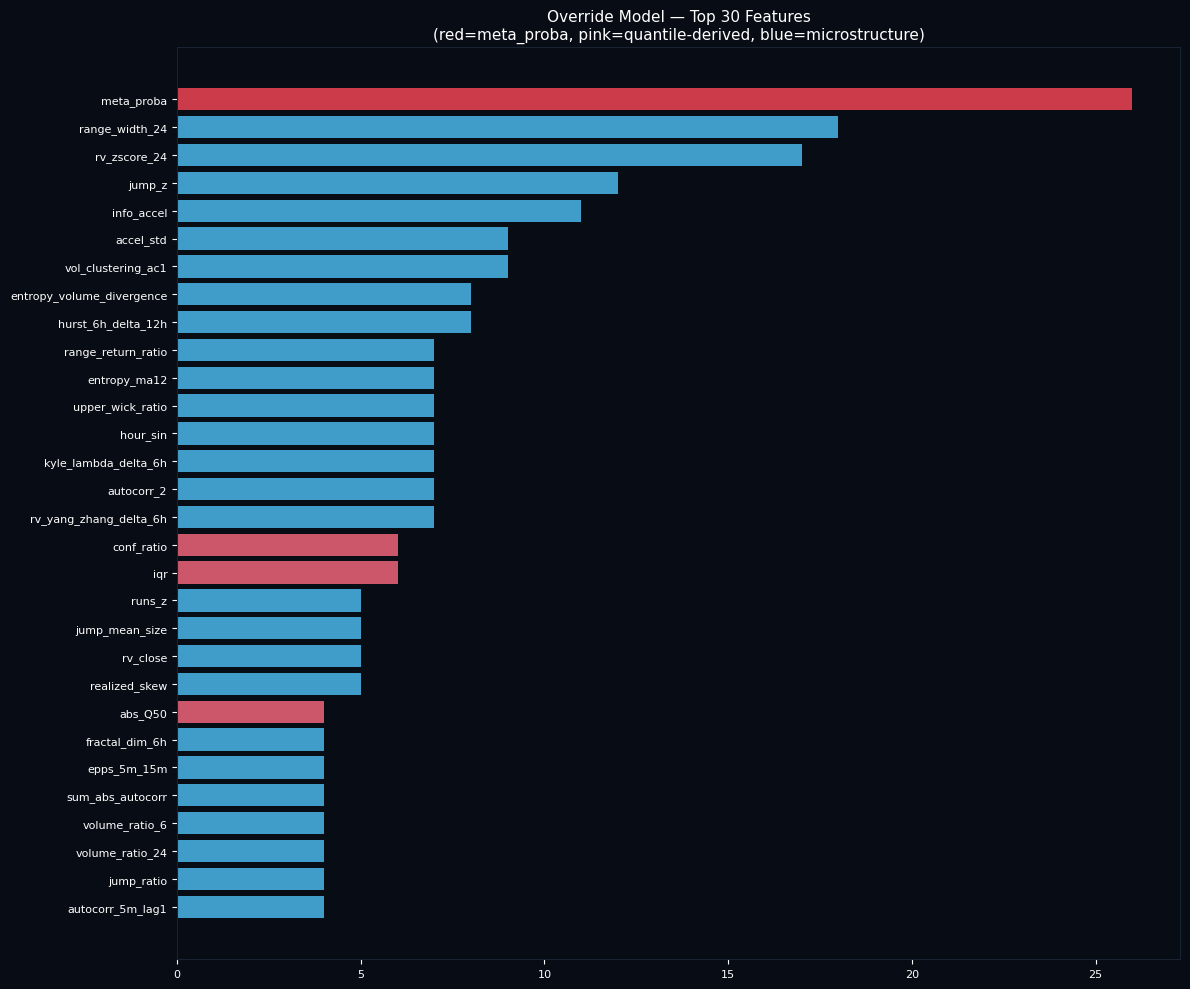


Top 15 features:
   1. meta_proba: 26 ← meta_proba
   2. range_width_24: 18
   3. rv_zscore_24: 17
   4. jump_z: 12
   5. info_accel: 11
   6. accel_std: 9
   7. vol_clustering_ac1: 9
   8. entropy_volume_divergence: 8
   9. hurst_6h_delta_12h: 8
  10. range_return_ratio: 7
  11. entropy_ma12: 7
  12. upper_wick_ratio: 7
  13. hour_sin: 7
  14. kyle_lambda_delta_6h: 7
  15. autocorr_2: 7


In [27]:
# Feature importance — what makes the override model say "trade this despite low meta"
importance = pd.Series(final_override.feature_importances_, index=override_feature_cols)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

top30 = importance.tail(30)
colors = ['#ff4757' if f == 'meta_proba' else
          '#ff6b81' if f in ['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio'] else
          '#4fc3f7' for f in top30.index]
ax.barh(top30.index, top30.values, color=colors, alpha=0.8)
ax.set_facecolor('#080c14')
ax.tick_params(colors='white', labelsize=8)
ax.set_title('Override Model — Top 30 Features\n(red=meta_proba, pink=quantile-derived, blue=microstructure)',
             color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
for i, (feat, imp) in enumerate(importance.tail(15).iloc[::-1].items(), 1):
    tag = ' ← meta_proba' if feat == 'meta_proba' else ''
    print(f'  {i:2}. {feat}: {imp}{tag}')

## 9. Summary

In [28]:
print('=' * 70)
print('OVERRIDE MODEL — SUMMARY')
print('=' * 70)
print(f'Purpose: detect when meta model is underconfident')
print(f'Input:   {len(override_feature_cols)} features (all meta features + meta_proba itself)')
print(f'Target:  did Q50 direction prediction win?')
print(f'CV AUC:  {np.mean(override_aucs):.4f}')
print(f'Saved:   {OVERRIDE_DIR / "override_confidence.joblib"}')
print(f'\nUsage in live/sim:')
print(f'  Step 1: compute Q50/Q25/Q75 as usual')
print(f'  Step 2: compute meta_proba as usual')
print(f'  Step 3: compute override_proba using override model')
print(f'  Step 4: trade if (meta_proba > 0.50) OR (override_proba > threshold)')
print(f'          — override can rescue trades where meta_proba is 0.42-0.50')

OVERRIDE MODEL — SUMMARY
Purpose: detect when meta model is underconfident
Input:   119 features (all meta features + meta_proba itself)
Target:  did Q50 direction prediction win?
CV AUC:  0.5395
Saved:   ..\backend\models_6\override\override_confidence.joblib

Usage in live/sim:
  Step 1: compute Q50/Q25/Q75 as usual
  Step 2: compute meta_proba as usual
  Step 3: compute override_proba using override model
  Step 4: trade if (meta_proba > 0.50) OR (override_proba > threshold)
          — override can rescue trades where meta_proba is 0.42-0.50
